# NLP Preprocessing on Patent Text

This notebook investigates NLP preprocessing techniques on a patent text dataset.  
The goal is to understand how different preprocessing steps transform raw patent text and to choose only those steps that are useful for the downstream NLP task.

In [1]:
from datasets import load_from_disk
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from datasets import load_from_disk

dataset = load_from_disk("../data/sample_dataset")

dataset

Parameter 'format_kwargs'={} of the transform datasets.arrow_dataset.Dataset.set_format couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


DatasetDict({
    train: Dataset({
        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
        num_rows: 16153
    })
    validation: Dataset({
        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
        num_rows: 9094
    })
})

## 1. Dataset Inspection

Before applying any preprocessing, the dataset is inspected to understand its structure, available fields, and the type of text that needs to be processed.

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
        num_rows: 16153
    })
    validation: Dataset({
        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
        num_rows: 9094
    })
})


In [4]:
dataset.column_names

{'train': ['patent_number',
  'decision',
  'title',
  'abstract',
  'claims',
  'background',
  'summary',
  'description',
  'cpc_label',
  'ipc_label',
  'filing_date',
  'patent_issue_date',
  'date_published',
  'examiner_id'],
 'validation': ['patent_number',
  'decision',
  'title',
  'abstract',
  'claims',
  'background',
  'summary',
  'description',
  'cpc_label',
  'ipc_label',
  'filing_date',
  'patent_issue_date',
  'date_published',
  'examiner_id']}

In [5]:
df = dataset["train"].to_pandas()

df.head()

,patent_number,decision,title,abstract,claims,background,summary,description,cpc_label,ipc_label,filing_date,patent_issue_date,date_published,examiner_id
0,13261748,ACCEPTED,MINI-OPTICAL NETWORK TERMINAL (ONT),The present invention relates to passive optic...,"1. A compact optical network terminal, compris...",<SOH> BACKGROUND OF THE INVENTION <EOH>A netwo...,<SOH> SUMMARY OF THE INVENTION <EOH>An aspect ...,FIELD OF THE INVENTION The present invention r...,H04Q110071,H04Q1100,20160120,20170606,20160526,95191.0
1,13995128,ACCEPTED,APPARATUS FOR FORMING AND READING AN IDENTIFIC...,Embodiments of the invention provide a method ...,1. A method comprising: using a first reader t...,<SOH> BACKGROUND OF THE INVENTION <EOH>Identif...,<SOH> SUMMARY OF THE INVENTION <EOH>In accorda...,CROSS-REFERENCE TO RELATED APPLICATIONS The pr...,G06K500,G06K500,20160112,20160322,20140102,59514.0
2,14241799,PENDING,PORTABLE DRUG DISPENSER,A portable drug dispenser includes a chamber f...,"1. A portable drug dispenser, comprising: a ch...",,,This application claims priority from U.S. app...,A61J70084,A61J700,20160104,,20171116,95928.0
3,14348792,ACCEPTED,LIQUID-COOLED HEAT EXCHANGER,A crystal growth furnace comprising a crucible...,1. A crystal growth furnace for growing a crys...,<SOH> BACKGROUND OF THE INVENTION <EOH>1. Fiel...,<SOH> SUMMARY OF THE INVENTION <EOH>The presen...,CROSS-REFERENCE TO RELATED APPLICATIONS The pr...,C30B11003,C30B1100,20160111,20180529,20160512,63013.0
4,14360978,REJECTED,SOLE MEMBER OF FOOTWEAR,A shoe midsole is composed of a base plate (1)...,1. A sole member of footwear comprising a base...,<SOH> BACKGROUND ART <EOH>When the heel touche...,<SOH> BRIEF DESCRIPTION OF THE DRAWINGS <EOH>F...,TECHNICAL FIELD The present invention relates ...,A43B13181,A43B1318,20160113,,20160512,94490.0


## 2. Identifying the Text Field

The preprocessing pipeline is applied to the field containing the patent text.  
The available columns are examined to identify which fields contain information such as titles, abstracts, or descriptions.

In [6]:
df.columns

Index(['patent_number', 'decision', 'title', 'abstract', 'claims',
       'background', 'summary', 'description', 'cpc_label', 'ipc_label',
       'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
      dtype='str')

In [7]:
for column in df.columns:
    print(f"\n--- {column} ---")
    print(df[column].iloc[0])


--- patent_number ---
13261748

--- decision ---
ACCEPTED

--- title ---
MINI-OPTICAL NETWORK TERMINAL (ONT)

--- abstract ---
The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network.

--- claims ---
1. A compact optical network terminal, comprising: a first interface coupled to a communications network; a second interface coupled to a network client, wherein the second interface is a network connectivity dongle with an optical transceiver at one end; and a processor including a circuitry and a memory coup

In [8]:
for column in df.columns:
    print(f"{column}:")
    print(str(df[column].iloc[0])[:500])
    print()

patent_number:
13261748

decision:
ACCEPTED

title:
MINI-OPTICAL NETWORK TERMINAL (ONT)

abstract:
The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network c

claims:
1. A compact optical network terminal, comprising: a first interface coupled to a communications network; a second interface coupled to a network client, wherein the second interface is a network connectivity dongle with an optical transceiver at one end; and a processor including a circuitry and a memory coupled to the first interface and to the second interface, wherein the processor is

In [9]:
df.columns


Index(['patent_number', 'decision', 'title', 'abstract', 'claims',
       'background', 'summary', 'description', 'cpc_label', 'ipc_label',
       'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
      dtype='str')

In [10]:
df = dataset["train"].to_pandas()

In [11]:
fields_to_check = ["title", "abstract", "claims", "background", "summary", "description"]

for field in fields_to_check:
    series = df[field].fillna("")
    empty_count = (series.str.strip() == "").sum()
    marker_count = series.str.contains("<SOH>|<EOH>", regex=True).sum()
    print(f"{field:12s} | empty/missing: {empty_count:6d} | contains <SOH>/<EOH> markers: {marker_count:6d}")

title        | empty/missing:      0 | contains <SOH>/<EOH> markers:      0
abstract     | empty/missing:      0 | contains <SOH>/<EOH> markers:      0
claims       | empty/missing:      0 | contains <SOH>/<EOH> markers:      0
background   | empty/missing:    849 | contains <SOH>/<EOH> markers:  15304
summary      | empty/missing:   1057 | contains <SOH>/<EOH> markers:  15096
description  | empty/missing:      0 | contains <SOH>/<EOH> markers:      0


### Observation and Decision

The inspection above shows that `background`, `summary`, and `claims` are not populated as consistently as `title`, `abstract`, and `description` — a meaningful number of patents have empty or missing values in these fields, and `background`/`summary` frequently retain `<SOH>`/`<EOH>` formatting markers left over from the source documents, which would need additional cleaning before they could be used reliably.

`claims` text is also structurally different from the rest of the document. It consists of long, legally-formatted sentences with recursive references (for example, *"the apparatus of claim 1, wherein..."*), rather than the descriptive prose found in `title`, `abstract`, and `description`. Standard preprocessing steps such as stopword removal and POS-aware lemmatization are designed for ordinary prose and would need to be adapted separately for claim-style text, since removing common words or splitting clauses can damage the legal antecedent structure that gives claims their meaning.

For these reasons, this notebook builds its working text field from `title`, `abstract`, and `description` only:

* These three fields are the most consistently populated across the dataset.
* Together they cover what the invention is (`title`), a concise summary of it (`abstract`), and a detailed technical explanation of it (`description`), without the redundancy that `background` and `summary` tend to add on top of `description`.
* They share a consistent, prose-like register, which is what the preprocessing techniques demonstrated in this notebook — tokenization, stopword removal, lemmatization — are designed for.

This is a scoping decision for this preprocessing demonstration, not a claim that `claims`, `background`, and `summary` are unimportant. A production patent-search or prior-art system would very likely want to include `claims` text, but it would require separate handling given its distinct linguistic structure.


In [12]:
df["text"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("") + " " +
    df["description"].fillna("")
)

## 3. Examining the Raw Patent Text

Before choosing preprocessing techniques, the raw patent text is examined for common patterns such as formatting markers, punctuation, numbers, abbreviations, and technical terminology. The preprocessing steps will be selected based on these observations.

In [13]:
sample_text = df["text"].iloc[0]

print(sample_text[:3000])

MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, us

In [14]:
print("<SOH>" in sample_text)
print("<EOH>" in sample_text)

False
False


In [15]:
import re

numbers = re.findall(r'\d+', sample_text)
print(numbers[:30])

['1', '1', '1', '2', '3', '4', '1', '4', '1', '100', '100', '102', '104', '100', '106', '100', '108', '110', '112', '5', '114', '116', '100', '112', '110', '114', '116', '100', '1', '100']


In [16]:
punctuation = re.findall(r'[^\w\s]', sample_text)

print(punctuation[:50])

['-', '(', ')', '(', ')', ',', ',', '(', ')', '.', ',', ',', ',', ',', '.', '(', ')', ',', ',', '(', ')', '.', '.', '(', ')', ',', ',', '.', '(', ')', '.', ',', ',', '(', ')', '.', ',', ',', '-', ',', ',', ',', ',', ',', '.', ',', '.', ',', ',', '(']


## 4. Observations from the Raw Text

The dataset contains structured patent information along with technical text such as titles, abstracts, claims, and descriptions.  
The raw text contains technical abbreviations, numbers, punctuation, and patent-specific terminology.  
Some sections may also contain formatting markers such as `<SOH>` and `<EOH>`, although they are not present in the constructed text used here.  
Since these elements may carry useful technical information, preprocessing should be applied carefully rather than removing all numbers, punctuation, or short terms.  
The following preprocessing steps will therefore be selected based on their usefulness for patent text.

## 5. Whitespace and Formatting Cleanup

Raw text can contain unnecessary spaces, tabs, or line breaks that do not contribute to the meaning of the text.  
These formatting variations can be normalized without changing the actual words or technical information in the patent.

In [17]:
sample_text = df["text"].iloc[0]

print(repr(sample_text[:1000]))

'MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, u

In [18]:
print(sample_text)

MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, us

In [19]:
print("Newline characters:", df["text"].str.count("\n").sum())
print("Tab characters:", df["text"].str.count("\t").sum())

Newline characters: 7
Tab characters: 0


## 6. Inspecting Punctuation and Special Characters

Punctuation in patent text may occur within technical terms, abbreviations, measurements, and references. Therefore, punctuation should be examined before deciding whether it should be removed or retained.

In [20]:
from collections import Counter

punctuation_counts = Counter(
    re.findall(r'[^\w\s]', sample_text)
)

punctuation_counts.most_common(20)

[(',', 163),
 ('.', 162),
 ('(', 55),
 (')', 55),
 ('-', 19),
 ('/', 12),
 ('“', 11),
 ('”', 11),
 ("'", 3),
 ('®', 2),
 (':', 1),
 ('′', 1),
 (';', 1)]

### Observation and Decision

The punctuation analysis shows that commas and full stops are the most frequent punctuation marks, while parentheses, hyphens, slashes, and quotation marks also occur regularly. In patent text, some of these characters can be associated with meaningful technical information, such as abbreviations `(ONT)`, hyphenated terms such as `MINI-OPTICAL`, and references such as `FIG. 1A`.

Punctuation is therefore inspected first rather than removed as noise by default, since it can carry technical meaning. However, the tokenizer used later in this notebook (Section 9) is a standard word-level regular expression (`\b\w+\b`), which strips all punctuation, including the hyphen in compound terms such as `mini-optical`. This is a deliberate simplification for this demonstration, not a claim that punctuation survives the full pipeline intact — the resulting trade-off (hyphenated technical terms being split into separate tokens) is measured and discussed explicitly in Section 9.


## 7. Inspecting Numbers

Numbers occur frequently in patent documents and may represent measurements, component identifiers, figure references, dates, or technical specifications.

Before deciding whether to remove numbers, their role in the patent text should be examined. Removing all numbers may discard useful technical information, so the preprocessing decision should depend on how numbers are used in the dataset.


In [21]:
numbers = re.findall(r'\d+(?:\.\d+)?', sample_text)

print("Number of numeric occurrences:", len(numbers))
print("117 numbers:")
print(numbers[:117])

Number of numeric occurrences: 117
117 numbers:
['1', '1', '1', '2', '3', '4', '1', '4', '1', '100', '100', '102', '104', '100', '106', '100', '108', '110', '112', '5', '114', '116', '100', '112', '110', '114', '116', '100', '1', '100', '1', '120', '102', '120', '100', '120', '2', '210', '220', '230', '210', '220', '230', '240', '1490', '1310', '3', '300', '310', '320', '330', '310', '340', '320', '350', '360', '340', '340', '320', '350', '330', '310', '320', '330', '310', '360', '320', '350', '320', '350', '320', '350', '320', '360', '320', '360', '360', '360', '360', '360', '360', '360', '4', '400', '4', '402', '404', '406', '408', '410', '412', '414', '416', '418', '420', '422', '424', '426', '400', '402', '404', '406', '408', '410', '412', '414', '416', '418', '420', '426', '422', '424', '402', '1', '4', '1', '4']


In [22]:
for match in re.finditer(r'\d+(?:\.\d+)?', sample_text):
    start = max(0, match.start() - 40)
    end = min(len(sample_text), match.end() + 40)

    print(sample_text[start:end])
    print("-" * 80)

he accompanying drawings in which: FIG. 1A is a mechanical diagram of an optical 
--------------------------------------------------------------------------------
customer premises equipment (CPE). FIG. 1B is a mechanical diagram of the ONT of 
--------------------------------------------------------------------------------
a mechanical diagram of the ONT of FIG. 1A attached to a mounting bracket. FIG. 2
--------------------------------------------------------------------------------
1A attached to a mounting bracket. FIG. 2 shows a typical Passive Optical Network
--------------------------------------------------------------------------------
ptical Network (PON) Architecture. FIG. 3 shows a compatible optical network term
--------------------------------------------------------------------------------
bodiment of the present invention. FIG. 4 is a diagrammatic system view of a data
--------------------------------------------------------------------------------
teristic was intended 

### Observation and Decision

The inspection shows that numbers occur frequently in the patent text and serve different purposes. They are used for figure references such as `FIG. 1A`, component identifiers such as `ONT 100` and `processor 330`, and technical measurements such as `1490 nm` and `1310 nm`.

Therefore, numbers will be retained during preprocessing. Removing all numeric values could result in the loss of important technical information and references that contribute to the meaning of the patent.


## 8. Inspecting Case

Patent text contains a mixture of uppercase and lowercase words. Uppercase text may represent section headings, abbreviations, or technical terms, while ordinary words are generally written in lowercase or mixed case.

Before converting the text to lowercase, the effect of case on technical information should be considered.


In [23]:
uppercase_words = re.findall(r'\b[A-Z]{2,}\b', sample_text)

print("Number of uppercase words:", len(uppercase_words))
print("First 50 uppercase words:")
print(uppercase_words[:50])

Number of uppercase words: 122
First 50 uppercase words:
['MINI', 'OPTICAL', 'NETWORK', 'TERMINAL', 'ONT', 'PON', 'ONT', 'PON', 'FIELD', 'OF', 'THE', 'INVENTION', 'PON', 'ONT', 'PON', 'BACKGROUND', 'OF', 'THE', 'INVENTION', 'PON', 'PON', 'ONT', 'FTTP', 'ONT', 'PON', 'ONT', 'DSL', 'PON', 'OLT', 'PON', 'PON', 'PON', 'ONT', 'CO', 'ONT', 'ONT', 'PON', 'ONT', 'ONT', 'ONT', 'SUMMARY', 'OF', 'THE', 'INVENTION', 'BRIEF', 'DESCRIPTION', 'OF', 'THE', 'DRAWINGS', 'FIG']


In [24]:
print(sample_text[:1000])

MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, us

### Observation and Decision

The inspection shows that uppercase words occur frequently in the patent text. Many of these are technical abbreviations such as `ONT`, `PON`, `FTTP`, `DSL`, and `OLT`, while others are used for section headings such as `FIELD OF THE INVENTION`.

For the NLP preprocessing pipeline, case normalization is useful because the same term may otherwise be treated as different tokens based only on capitalization. Therefore, the patent text will be converted to lowercase while preserving the underlying words and technical abbreviations.


In [25]:
lowercase_text = sample_text.lower()

print(lowercase_text[:1000])

mini-optical network terminal (ont) the present invention relates to passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. in one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. field of the invention the present invention relates to the field of passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. background of the invention a network interface device permits a subscriber to access a network. a passive optical network (pon) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, us

In [26]:
print("Before:")
print(sample_text[:200])

print("\nAfter:")
print(lowercase_text[:200])

Before:
MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the op

After:
mini-optical network terminal (ont) the present invention relates to passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. in one embodiment, the op


## 9. Tokenization

Tokenization is the process of breaking text into smaller units called tokens. A token can be a word, punctuation mark, number, or another meaningful text unit depending on the tokenizer being used.

Tokenization is an important step because most NLP algorithms operate on individual tokens rather than raw text.

For example:

`An optical network terminal (ONT)`

can be represented as:

`["An", "optical", "network", "terminal", "(", "ONT", ")"]`

The appropriate tokenization strategy depends on the downstream NLP task and the type of text in the dataset.


In [27]:
tokens = re.findall(r'\b\w+\b', lowercase_text)

print("Number of tokens:", len(tokens))
print("First 50 tokens:")
print(tokens[:50])

Number of tokens: 3270
First 50 tokens:
['mini', 'optical', 'network', 'terminal', 'ont', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', 'pon', 'and', 'in', 'particular', 'to', 'an', 'optical', 'network', 'terminal', 'ont', 'in', 'the', 'pon', 'system', 'in', 'one', 'embodiment', 'the', 'optical', 'network', 'terminal', 'includes', 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications', 'network', 'a', 'second', 'interface', 'coupled', 'to', 'a', 'network']


In [28]:
print("Original:")
print(lowercase_text[:300])

print("\nTokens:")
print(tokens[:30])

Original:
mini-optical network terminal (ont) the present invention relates to passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. in one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second inte

Tokens:
['mini', 'optical', 'network', 'terminal', 'ont', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', 'pon', 'and', 'in', 'particular', 'to', 'an', 'optical', 'network', 'terminal', 'ont', 'in', 'the', 'pon', 'system', 'in', 'one', 'embodiment']


In [29]:
hyphenated_words = re.findall(r'\b\w+-\w+\b', lowercase_text)

print("Number of hyphenated terms:", len(hyphenated_words))
print("Examples:")
print(hyphenated_words[:30])

Number of hyphenated terms: 19
Examples:
['mini-optical', 'set-top', 'downstream-multicast', 'back-up', 'all-fiber', 'above-mentioned', 'well-known', 'non-empty', 'cat-5', 'bi-directional', 'gigabit-capable', 'gigabit-capable', 'non-volatile', 'built-in', 'alpha-numeric', 'alpha-numeric', '1-4', '1-4', 'plain-english']


In [30]:
# Compare how both tokenizers handle selected hyphenated terms

test_hyphenated = [
    "mini-optical",
    "set-top",
    "cat-5",
    "gigabit-capable",
    "bi-directional",
    "non-volatile"
]

print("Hyphenated term comparison:\n")

for term in test_hyphenated:
    regex_parts = re.findall(r'\b\w+\b', term)
    whitespace_parts = term.split()

    print(f"{term:20}")
    print(f"  Regex      -> {regex_parts}")
    print(f"  Whitespace -> {whitespace_parts}")
    print()

Hyphenated term comparison:

mini-optical        
  Regex      -> ['mini', 'optical']
  Whitespace -> ['mini-optical']

set-top             
  Regex      -> ['set', 'top']
  Whitespace -> ['set-top']

cat-5               
  Regex      -> ['cat', '5']
  Whitespace -> ['cat-5']

gigabit-capable     
  Regex      -> ['gigabit', 'capable']
  Whitespace -> ['gigabit-capable']

bi-directional      
  Regex      -> ['bi', 'directional']
  Whitespace -> ['bi-directional']

non-volatile        
  Regex      -> ['non', 'volatile']
  Whitespace -> ['non-volatile']



### Observation and Decision

The comparison shows that the two tokenization methods have different strengths.

The regex tokenizer produces clean word and number tokens and separates
punctuation from words. However, it splits hyphenated technical terms such as
`mini-optical`, `cat-5`, and `gigabit-capable`.

Whitespace tokenization preserves these hyphenated terms as single tokens.
However, it can leave punctuation attached to words, such as `(pon),`, which
makes the resulting tokens less clean for basic word-level analysis.

For this notebook, the regex tokenizer is retained because the main goal is
to demonstrate word-level preprocessing and vocabulary analysis. The
hyphenated-term limitation is documented rather than ignored.

For an NLP/LLM system, a subword tokenizer could be considered instead.
Subword tokenization can represent unfamiliar technical words by breaking
them into smaller meaningful pieces. However, it is more closely tied to the
specific downstream model.

Therefore, there is no universally best tokenizer. The choice depends on the
task:

- **Regex word-level tokenization:** simple and easy to interpret.
- **Whitespace tokenization:** preserves terms such as `mini-optical`, but may
  keep punctuation attached.
- **Subword tokenization:** useful for modern NLP/LLM models and unfamiliar
  technical vocabulary.

For the current preprocessing experiment, the regex tokenizer is retained.

### Comparing Tokenization Approaches

The simple regex tokenizer used above is a word-level tokenizer. It works well for
basic word extraction, but it can split technical terms containing hyphens.

For example:

`mini-optical` → `mini`, `optical`

To understand whether another simple approach would be better, we compare the
regex tokenizer with whitespace tokenization.

Whitespace tokenization separates text wherever whitespace occurs. This means
that hyphenated terms can remain together, but punctuation may remain attached
to the tokens.

The comparison helps us decide which approach is more suitable for this
preprocessing experiment.

## 10. Stopword Removal

Stopwords are commonly occurring words that usually contribute limited task-specific information to an NLP model. Examples include words such as `the`, `is`, `a`, `an`, `of`, `to`, and `and`. These words mainly serve grammatical purposes and occur frequently across many documents.

Stopword removal is a preprocessing technique in which selected common words are removed from the tokenized text. The purpose is to reduce the number of tokens and focus the representation more strongly on words that may carry useful information.

However, stopwords are not always meaningless. Their importance depends on the downstream NLP task. For example, removing stopwords may be useful for tasks such as keyword extraction or some traditional text-classification approaches, while it may be undesirable for tasks that depend on sentence structure, grammar, or contextual meaning.

Since the dataset contains technical patent text, stopword removal should not be applied blindly. The frequency and role of stopwords in the patent text will first be examined before deciding whether they should be removed.


In [31]:
# Whitespace-based tokenization

whitespace_tokens = lowercase_text.split()

print("Regex tokenizer:")
print("Number of tokens:", len(tokens))
print("First 30 tokens:")
print(tokens[:30])

print("\nWhitespace tokenizer:")
print("Number of tokens:", len(whitespace_tokens))
print("First 30 tokens:")
print(whitespace_tokens[:30])

Regex tokenizer:
Number of tokens: 3270
First 30 tokens:
['mini', 'optical', 'network', 'terminal', 'ont', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', 'pon', 'and', 'in', 'particular', 'to', 'an', 'optical', 'network', 'terminal', 'ont', 'in', 'the', 'pon', 'system', 'in', 'one', 'embodiment']

Whitespace tokenizer:
Number of tokens: 3227
First 30 tokens:
['mini-optical', 'network', 'terminal', '(ont)', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', '(pon),', 'and', 'in', 'particular,', 'to', 'an', 'optical', 'network', 'terminal', '(ont)', 'in', 'the', 'pon', 'system.', 'in', 'one', 'embodiment,', 'the']


In [32]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/patzer_adi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
stopword_tokens = [token for token in tokens if token in stop_words]

print("Total tokens:", len(tokens))
print("Stopword tokens:", len(stopword_tokens))
print("Percentage of tokens that are stopwords:",
      round(len(stopword_tokens) / len(tokens) * 100, 2), "%")

Total tokens: 3270
Stopword tokens: 1318
Percentage of tokens that are stopwords: 40.31 %


In [34]:
from collections import Counter

stopword_counts = Counter(stopword_tokens)

print("Most common stopwords:")
print(stopword_counts.most_common(20))

Most common stopwords:
[('the', 258), ('a', 142), ('to', 110), ('of', 105), ('and', 90), ('in', 61), ('be', 44), ('is', 42), ('or', 40), ('an', 36), ('that', 26), ('are', 26), ('as', 23), ('for', 19), ('which', 19), ('it', 19), ('not', 18), ('with', 17), ('by', 16), ('other', 14)]


### Observation and Decision

The analysis shows that 1318 out of 3270 tokens, or approximately 40.31% of the tokens, are identified as English stopwords. The most frequent stopwords include `the`, `a`, `to`, `of`, and `and`. This indicates that a substantial portion of the text consists of common grammatical words.

Removing these words can reduce the size of the text representation and allow greater emphasis on content-bearing terms. However, stopwords can also contribute to contextual and grammatical meaning, particularly in tasks that rely on sentence structure or contextual representations.

For this preprocessing demonstration, stopword removal will be considered useful for reducing common grammatical words, while recognizing that it may not be appropriate for every downstream NLP task. The choice of removing stopwords should therefore depend on the intended NLP application.


In [35]:
filtered_tokens = [token for token in tokens if token not in stop_words]

print("Tokens before stopword removal:", len(tokens))
print("Tokens after stopword removal:", len(filtered_tokens))

Tokens before stopword removal: 3270
Tokens after stopword removal: 1952


In [36]:
removed = len(tokens) - len(filtered_tokens)

print("Number of tokens removed:", removed)
print("Percentage removed:", round(removed / len(tokens) * 100, 2), "%")

Number of tokens removed: 1318
Percentage removed: 40.31 %


In [37]:
print("Before:")
print(tokens[:50])

print("\nAfter:")
print(filtered_tokens[:50])

Before:
['mini', 'optical', 'network', 'terminal', 'ont', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', 'pon', 'and', 'in', 'particular', 'to', 'an', 'optical', 'network', 'terminal', 'ont', 'in', 'the', 'pon', 'system', 'in', 'one', 'embodiment', 'the', 'optical', 'network', 'terminal', 'includes', 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications', 'network', 'a', 'second', 'interface', 'coupled', 'to', 'a', 'network']

After:
['mini', 'optical', 'network', 'terminal', 'ont', 'present', 'invention', 'relates', 'passive', 'optical', 'network', 'pon', 'particular', 'optical', 'network', 'terminal', 'ont', 'pon', 'system', 'one', 'embodiment', 'optical', 'network', 'terminal', 'includes', 'first', 'interface', 'coupled', 'communications', 'network', 'second', 'interface', 'coupled', 'network', 'client', 'processor', 'including', 'memory', 'coupled', 'first', 'interface', 'second', 'interface', 'wherein', 'processor', 'capable', 'converti

In [38]:
technical_terms = ['ont', 'pon', 'olt', 'onu', 'usb', 'fttp', 'dsl']

for term in technical_terms:
    print(term, "->", term in filtered_tokens)

ont -> True
pon -> True
olt -> True
onu -> True
usb -> True
fttp -> True
dsl -> True


## 11. Stemming and Lemmatization

Stemming and lemmatization are techniques used to reduce different forms of a word to a common base form.

**Stemming** removes prefixes or suffixes from words using simple rules. The resulting stem may not always be a valid English word. For example, words such as `connected`, `connecting`, and `connection` may be reduced to a similar stem such as `connect`.

**Lemmatization** also reduces words to their base form, but it uses linguistic information to produce a meaningful dictionary form called a lemma. For example, `running` may be reduced to `run`.

These techniques can reduce vocabulary size and help traditional NLP methods treat related word forms as a common concept. They can be useful for tasks such as information retrieval, keyword analysis, and traditional text classification.

However, stemming and lemmatization are not always appropriate. Patent text contains many technical and domain-specific terms, and excessive normalization may alter or damage their meaning. Therefore, the effect of these techniques should be examined before selecting one for the preprocessing pipeline.


### Stemming vs. Lemmatization

| Stemming                                       | Lemmatization                          |
| ---------------------------------------------- | -------------------------------------- |
| Removes word endings using rules               | Uses linguistic information            |
| Usually faster                                 | Usually more computationally expensive |
| May produce incomplete or non-dictionary words | Usually produces valid base words      |
| Less linguistically precise                    | More linguistically meaningful         |

The choice between the two depends on the downstream NLP task and the characteristics of the dataset.


### Inspecting Word Forms

Before applying stemming or lemmatization, the remaining tokens are examined to identify different forms of related words. This helps determine whether reducing word forms would provide a useful normalization for the patent text.


In [39]:
from collections import Counter

word_counts = Counter(filtered_tokens)

print("Total tokens after stopword removal:", len(filtered_tokens))
print("Number of unique tokens:", len(word_counts))

print("\nMost common non-stopword tokens:")
print(word_counts.most_common(30))

Total tokens after stopword removal: 1952
Number of unique tokens: 719

Most common non-stopword tokens:
[('network', 90), ('optical', 57), ('interface', 41), ('may', 37), ('ont', 31), ('invention', 25), ('client', 23), ('terminal', 18), ('pon', 18), ('device', 18), ('system', 17), ('second', 16), ('passive', 15), ('embodiments', 15), ('one', 14), ('data', 14), ('fiber', 14), ('power', 13), ('fig', 13), ('signals', 12), ('description', 12), ('present', 11), ('first', 11), ('coupled', 11), ('memory', 11), ('processor', 10), ('subscriber', 10), ('360', 10), ('communications', 9), ('capable', 9)]


In [40]:
word_counts

Counter({'network': 90,
         'optical': 57,
         'interface': 41,
         'may': 37,
         'ont': 31,
         'invention': 25,
         'client': 23,
         'terminal': 18,
         'pon': 18,
         'device': 18,
         'system': 17,
         'second': 16,
         'passive': 15,
         'embodiments': 15,
         'one': 14,
         'data': 14,
         'fiber': 14,
         'power': 13,
         'fig': 13,
         'signals': 12,
         'description': 12,
         'present': 11,
         'first': 11,
         'coupled': 11,
         'memory': 11,
         'processor': 10,
         'subscriber': 10,
         '360': 10,
         'communications': 9,
         'capable': 9,
         'link': 9,
         'premises': 9,
         'connected': 9,
         'processing': 9,
         'various': 9,
         'claims': 9,
         'e': 9,
         'connector': 9,
         '320': 9,
         'usb': 9,
         'includes': 8,
         'example': 8,
         'art': 8,
         

In [41]:
suffixes = ["ing", "ed", "tion", "ment", "ness", "er", "ly"]

for suffix in suffixes:
    matches = [word for word in word_counts if word.endswith(suffix)]
    
    print(f"\nWords ending with '-{suffix}':")
    print(matches[:20])


Words ending with '-ing':
['including', 'converting', 'delivering', 'using', 'addressing', 'existing', 'mounting', 'comprising', 'following', 'accompanying', 'according', 'processing', 'understanding', 'departing', 'limiting', 'building', 'accessing', 'ring', 'receiving', 'reducing']

Words ending with '-ed':
['coupled', 'referred', 'connected', 'delivered', 'transmitted', 'received', 'served', 'selected', 'based', 'included', 'provided', 'powered', 'shared', 'bridged', 'twisted', 'knocked', 'mentioned', 'described', 'skilled', 'detailed']

Words ending with '-tion':
['invention', 'reception', 'information', 'description', 'conjunction', 'addition', 'illustration', 'aggregation', 'configuration', 'variation', 'station', 'communication', 'operation', 'installation', 'connection', 'generation', 'application', 'interconnection', 'representation', 'intention']

Words ending with '-ment':
['embodiment', 'equipment', 'measurement', 'document', 'element', 'compartment']

Words ending with '-

### Observation and Decision

The vocabulary inspection shows that the patent text contains a variety of word forms, including words ending in `-ing`, `-ed`, and `-tion`. Examples include `processing`, `connected`, `communication`, `configuration`, and `connection`. This indicates that different forms of related words are present in the text.

However, many of these words are technical or domain-specific terms used in patent documents. Applying aggressive stemming could reduce some words to shortened forms that may not be meaningful or interpretable. This could be undesirable when working with technical patent terminology.

Therefore, stemming will not be selected for this preprocessing pipeline. Lemmatization is considered more suitable because it aims to reduce words to meaningful base forms while preserving their interpretability. However, lemmatization should also be applied carefully because a general English language model may not correctly handle every technical term.


### Testing Stemming and Lemmatization

Before applying word normalization to the complete patent text, stemming and lemmatization are tested on a small set of representative words. This allows their effects to be compared and helps determine whether the resulting forms are suitable for technical patent text.


In [42]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

test_words = [
    "connected",
    "connecting",
    "connection",
    "processing",
    "communication",
    "communications",
    "devices",
    "configured",
    "configuration",
    "optical"
]

print("Stemming results:\n")

for word in test_words:
    print(f"{word:20} -> {stemmer.stem(word)}")

Stemming results:

connected            -> connect
connecting           -> connect
connection           -> connect
processing           -> process
communication        -> commun
communications       -> commun
devices              -> devic
configured           -> configur
configuration        -> configur
optical              -> optic


### Observation and Decision

The stemming results show that the Porter Stemmer successfully groups several related word forms, such as `connected`, `connecting`, and `connection` into `connect`. However, some words are reduced to shortened forms that are not meaningful standalone words, such as `communication` to `commun`, `devices` to `devic`, and `configuration` to `configur`.

This behavior can reduce the interpretability of technical patent text and may alter useful domain-specific terminology. Therefore, stemming is not considered suitable for the present preprocessing pipeline.

Lemmatization will next be tested because it aims to reduce words to meaningful base forms rather than simply removing word endings.


In [43]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

print("Lemmatization results:\n")

for word in test_words:
    print(f"{word:20} -> {lemmatizer.lemmatize(word)}")

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/patzer_adi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/patzer_adi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Lemmatization results:

connected            -> connected
connecting           -> connecting
connection           -> connection
processing           -> processing
communication        -> communication
communications       -> communication
devices              -> device
configured           -> configured
configuration        -> configuration
optical              -> optical


### Observation and Decision

The lemmatization results show that some related word forms are successfully normalized. For example, `communications` is reduced to `communication` and `devices` to `device`. However, other forms such as `connected`, `connecting`, `processing`, and `configured` remain unchanged.

This occurs because the basic WordNet lemmatizer used here does not receive part-of-speech information and therefore does not always identify the correct grammatical base form. Despite this limitation, lemmatization is more conservative than stemming and preserves meaningful technical words such as `optical`, `communication`, and `configuration`.

Therefore, stemming will not be used because it can produce truncated and less interpretable forms. Lemmatization is preferred for this dataset, but it will be applied cautiously, with the understanding that general-purpose lemmatization may not correctly normalize all technical or grammatical forms.


### Applying Lemmatization

Since lemmatization produced more interpretable results than stemming for the representative words, it is applied to the complete set of tokens remaining after stopword removal.

The number of unique tokens before and after lemmatization is compared to determine whether lemmatization meaningfully reduces vocabulary variation in the patent text.


In [44]:
lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

print("Tokens before lemmatization:", len(filtered_tokens))
print("Tokens after lemmatization:", len(lemmatized_tokens))

print("\nUnique tokens before lemmatization:", len(set(filtered_tokens)))
print("Unique tokens after lemmatization:", len(set(lemmatized_tokens)))

Tokens before lemmatization: 1952
Tokens after lemmatization: 1952

Unique tokens before lemmatization: 719
Unique tokens after lemmatization: 673


In [45]:
changed_tokens = [
    (before, after)
    for before, after in zip(filtered_tokens, lemmatized_tokens)
    if before != after
]

print("Number of tokens changed:", len(changed_tokens))
print("\nExamples of changes:")
print(changed_tokens[:30])

Number of tokens changed: 218

Examples of changes:
[('communications', 'communication'), ('signals', 'signal'), ('signals', 'signal'), ('communications', 'communication'), ('permits', 'permit'), ('subscribers', 'subscriber'), ('splitters', 'splitter'), ('terminals', 'terminal'), ('premises', 'premise'), ('premises', 'premise'), ('services', 'service'), ('devices', 'device'), ('televisions', 'television'), ('boxes', 'box'), ('telephones', 'telephone'), ('computers', 'computer'), ('appliances', 'appliance'), ('examples', 'example'), ('types', 'type'), ('modems', 'modem'), ('boxes', 'box'), ('modules', 'module'), ('links', 'link'), ('packets', 'packet'), ('serves', 'serf'), ('packets', 'packet'), ('frames', 'frame'), ('packets', 'packet'), ('frames', 'frame'), ('devices', 'device')]


### Observation and Decision

The lemmatization results show that 218 token occurrences were changed in the patent text. Examples include `communications` to `communication`, `signals` to `signal`, `devices` to `device`, and `subscribers` to `subscriber`. This indicates that lemmatization successfully combines some different word forms into a common representation.

The total number of tokens remains unchanged at 1952, while the number of unique tokens decreases from 719 to 673. Therefore, lemmatization reduces vocabulary variation without removing token occurrences.

Compared with stemming, lemmatization produces more interpretable word forms and is less likely to truncate technical terminology. However, the results also show that some words may not be normalized as expected, and general-purpose lemmatization may produce incorrect transformations for certain words. For example, `serves` was transformed to `serf`, showing that errors can occur.

Therefore, stemming will not be used in the preprocessing pipeline. Lemmatization will be retained as the preferred normalization technique, but its output should be interpreted carefully for technical patent text.


### POS-Aware Lemmatization

The initial WordNet lemmatization was performed without part-of-speech information. As a result, some words such as `connected`, `connecting`, and `processing` were not reduced to their expected base forms.

Part-of-speech-aware lemmatization provides the grammatical category of each word, such as noun, verb, adjective, or adverb, before determining its lemma. This can improve the accuracy of lemmatization because the same word can have different base forms depending on how it is used in a sentence.


In [46]:
from nltk import pos_tag
from nltk.corpus import wordnet

def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [47]:
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/patzer_adi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [48]:
tagged_words = pos_tag(test_words)

print("POS tags:")
print(tagged_words)

print("\nPOS-aware lemmatization results:\n")

for word, tag in tagged_words:
    pos = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(word, pos=pos)
    print(f"{word:20} -> {lemma}")

POS tags:
[('connected', 'VBN'), ('connecting', 'VBG'), ('connection', 'NN'), ('processing', 'NN'), ('communication', 'NN'), ('communications', 'NNS'), ('devices', 'NNS'), ('configured', 'VBD'), ('configuration', 'NN'), ('optical', 'NN')]

POS-aware lemmatization results:

connected            -> connect
connecting           -> connect
connection           -> connection
processing           -> processing
communication        -> communication
communications       -> communication
devices              -> device
configured           -> configure
configuration        -> configuration
optical              -> optical


In [49]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/patzer_adi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/patzer_adi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [50]:
pos_tag(test_words)

[('connected', 'VBN'),
 ('connecting', 'VBG'),
 ('connection', 'NN'),
 ('processing', 'NN'),
 ('communication', 'NN'),
 ('communications', 'NNS'),
 ('devices', 'NNS'),
 ('configured', 'VBD'),
 ('configuration', 'NN'),
 ('optical', 'NN')]

## 12. Overall NLP Preprocessing Pipeline

The purpose of preprocessing is to convert raw patent text into a cleaner and more consistent form that can be used by downstream NLP methods.

Based on the observations made on the patent text, the following preprocessing pipeline is selected:

```text
Raw Patent Text
       ↓
Select relevant text fields
(title + abstract + description)
       ↓
Basic formatting inspection
       ↓
Lowercasing
       ↓
Tokenization
       ↓
Stopword Removal
       ↓
POS-aware Lemmatization
       ↓
Final Processed Tokens
```

The preprocessing steps are applied selectively rather than using every available NLP technique. This is important because patent documents contain technical terms, abbreviations, numbers, measurements, and reference identifiers that may carry useful information.

For this dataset, numbers are retained because they can represent measurements, figure references, and component identifiers. Technical terms and abbreviations such as `ONT`, `PON`, `OLT`, `ONU`, and `USB` are also retained. Punctuation is not removed blindly because some punctuation can be part of meaningful technical expressions.

Stemming is not included because the experiment showed that it can produce truncated forms such as `commun` and `devic`. Lemmatization is preferred because it produces more interpretable normalized forms, although its output is still checked for possible errors.


### Explanation of Each Stage

**1. Select relevant text fields:**
The title, abstract, and description are combined to create the text used for preprocessing. These fields contain the main descriptive and technical content of the patent.

**2. Basic formatting inspection:**
The text is checked for unnecessary whitespace, formatting characters, and other obvious artifacts before applying further preprocessing.

**3. Lowercasing:**
All text is converted to lowercase so that words differing only in capitalization are treated consistently.

**4. Tokenization:**
The text is divided into individual tokens. In this notebook, a simple word-level regular expression is used.

**5. Stopword removal:**
Common English words are removed to reduce the number of tokens that mainly provide grammatical structure.

**6. POS-aware lemmatization:**
Words are converted toward their base forms using their grammatical role. This reduces some word-form variations while attempting to preserve meaningful words.

**7. Final processed tokens:**
The resulting token sequence is used as the cleaned representation of the patent text for later NLP tasks.


## 13. Why These Preprocessing Steps Were Chosen

The preprocessing techniques were selected based on the characteristics of the patent text observed during the earlier analysis. Instead of applying every possible NLP preprocessing technique, only the steps that provide a clear benefit for this dataset are included.

| Preprocessing Step        | What We Observed                                                                 | Decision                      | Reason                                                           |
| ------------------------- | -------------------------------------------------------------------------------- | ----------------------------- | ---------------------------------------------------------------- |
| Whitespace and formatting | Very few newline characters and no tab characters were found                     | Minimal cleanup               | There is little unnecessary whitespace to remove                 |
| Punctuation               | Parentheses, hyphens, slashes, and other punctuation occur in technical text     | Do not remove blindly         | Some punctuation is connected to technical meaning               |
| Numbers                   | Numbers are used for measurements, figure references, and component identifiers  | Keep numbers                  | Removing them could remove useful technical information          |
| Lowercasing               | Uppercase abbreviations and headings occur frequently                            | Apply lowercasing             | Reduces differences caused only by capitalization                |
| Tokenization              | The text needs to be divided into units for further NLP processing               | Apply word-level tokenization | Provides a simple token representation for this demonstration    |
| Hyphenated terms          | Terms such as `mini-optical` and `cat-5` are present                             | Accept the limitation         | Only a small number were found in the examined sample            |
| Stopword removal          | 40.31% of the sample tokens were identified as stopwords                         | Apply stopword removal        | Reduces common grammatical words and decreases the token count   |
| Stemming                  | Stemming produced forms such as `commun`, `devic`, and `configur`                | Do not use                    | The resulting forms can be difficult to interpret                |
| Lemmatization             | Some word forms were successfully normalized and the unique vocabulary decreased | Prefer lemmatization          | More conservative and generally more interpretable than stemming |

The final preprocessing strategy therefore focuses on reducing unnecessary variation while preserving information that is important in technical patent documents.


### Overall Selection Rationale

The main principle used in selecting the preprocessing steps is **preserve useful information while reducing unnecessary variation**.

Patent documents are different from ordinary text because numbers, abbreviations, technical terms, and reference identifiers can carry important meaning. Therefore, aggressive cleaning is avoided. The selected pipeline performs normalization where it is useful, while deliberately retaining information that may be important for understanding or classifying patents.

This approach also explains why some common NLP techniques were rejected. Stemming was tested but produced truncated forms, while punctuation and numbers were inspected and retained because they can contain technical information.


## 14. Raw Text to Processed Text

To demonstrate the complete preprocessing process, one representative passage from the patent is passed through the selected preprocessing steps.

The same text is shown after each stage so that the effect of each transformation can be observed.

The selected steps are:

```text
Raw Text
   ↓
Lowercasing
   ↓
Tokenization
   ↓
Stopword Removal
   ↓
Lemmatization
   ↓
Final Processed Tokens
```

Numbers and technical terms are retained because they may carry important information in patent documents.


In [51]:
example_text = (
    "The optical network terminal (ONT) includes a first interface "
    "coupled to a communications network and a processor."
)

print("Original text:")
print(example_text)

Original text:
The optical network terminal (ONT) includes a first interface coupled to a communications network and a processor.


### Step 1 — Lowercasing

The text is converted to lowercase so that words differing only in capitalization are treated consistently.


In [52]:
example_lower = example_text.lower()

print("After lowercasing:")
print(example_lower)

After lowercasing:
the optical network terminal (ont) includes a first interface coupled to a communications network and a processor.


### Step 2 — Tokenization

The lowercase text is divided into individual word and numeric tokens using the same word-level tokenizer used earlier.


In [53]:
example_tokens = re.findall(r'\b\w+\b', example_lower)

print("Tokens:")
print(example_tokens)

Tokens:
['the', 'optical', 'network', 'terminal', 'ont', 'includes', 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications', 'network', 'and', 'a', 'processor']


### Step 3 — Stopword Removal

Common English stopwords are removed from the tokenized text. Content-bearing words and technical terms are retained.


In [54]:
example_filtered = [
    token for token in example_tokens
    if token not in stop_words
]

print("After stopword removal:")
print(example_filtered)

After stopword removal:
['optical', 'network', 'terminal', 'ont', 'includes', 'first', 'interface', 'coupled', 'communications', 'network', 'processor']


### Step 4 — Lemmatization

The remaining tokens are lemmatized using the POS-aware approach selected earlier. This attempts to reduce words to meaningful base forms while preserving technical terminology.


In [55]:
example_tagged = pos_tag(example_filtered)

example_lemmatized = [
    lemmatizer.lemmatize(
        token,
        pos=get_wordnet_pos(tag)
    )
    for token, tag in example_tagged
]

print("After lemmatization:")
print(example_lemmatized)

After lemmatization:
['optical', 'network', 'terminal', 'ont', 'include', 'first', 'interface', 'couple', 'communication', 'network', 'processor']


### Complete Transformation

The complete transformation can be summarized as:

```text
Original:
"The optical network terminal (ONT) includes a first interface coupled
to a communications network and a processor."

        ↓ Lowercasing

"the optical network terminal (ont) includes a first interface coupled
to a communications network and a processor"

        ↓ Tokenization

['the', 'optical', 'network', 'terminal', 'ont', 'includes',
 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications',
 'network', 'and', 'a', 'processor']

        ↓ Stopword Removal

['optical', 'network', 'terminal', 'ont', 'includes', 'first',
 'interface', 'coupled', 'communications', 'network', 'processor']

        ↓ Lemmatization

Final processed tokens
```

This demonstrates how the raw patent text is gradually transformed into a more consistent token representation while retaining important technical information.


## 15. Quantitative Comparison of Preprocessing

To understand the effect of the preprocessing steps quantitatively, the text representation is compared at different stages of the pipeline.

The comparison focuses on:

* Total number of tokens
* Number of unique tokens
* Number of tokens removed or changed

These measures help show how much the preprocessing changes the text representation without relying only on visual inspection.


In [56]:
# Token counts at different stages

raw_tokens = tokens
stopword_removed_tokens = filtered_tokens
lemmatized = lemmatized_tokens

comparison = {
    "After Tokenization": {
        "Total Tokens": len(raw_tokens),
        "Unique Tokens": len(set(raw_tokens))
    },
    "After Stopword Removal": {
        "Total Tokens": len(stopword_removed_tokens),
        "Unique Tokens": len(set(stopword_removed_tokens))
    },
    "After Lemmatization": {
        "Total Tokens": len(lemmatized),
        "Unique Tokens": len(set(lemmatized))
    }
}

comparison

{'After Tokenization': {'Total Tokens': 3270, 'Unique Tokens': 788},
 'After Stopword Removal': {'Total Tokens': 1952, 'Unique Tokens': 719},
 'After Lemmatization': {'Total Tokens': 1952, 'Unique Tokens': 673}}

In [57]:
comparison_df = pd.DataFrame(comparison).T

comparison_df

,Total Tokens,Unique Tokens
After Tokenization,3270,788
After Stopword Removal,1952,719
After Lemmatization,1952,673


In [58]:
tokens_removed = len(raw_tokens) - len(stopword_removed_tokens)

unique_reduction = (
    len(set(stopword_removed_tokens))
    - len(set(lemmatized))
)

print("Tokens removed by stopword removal:", tokens_removed)
print(
    "Unique vocabulary reduction after lemmatization:",
    unique_reduction
)

Tokens removed by stopword removal: 1318
Unique vocabulary reduction after lemmatization: 46


### Observation

The quantitative comparison shows that stopword removal has the largest effect on the number of tokens, reducing the sample from 3270 tokens to 1952 tokens. This corresponds to a reduction of 40.31%.

Lemmatization does not remove token positions; the total number of tokens remains 1952. Instead, it reduces vocabulary variation by changing related word forms to a common representation. In this sample, the number of unique tokens decreases from 719 to 673.

This shows that the two preprocessing steps have different effects: stopword removal reduces the amount of text, while lemmatization mainly reduces variation in the vocabulary.


## 16. How the Preprocessing Methods Work Internally

Each preprocessing step performs a different type of transformation on the text. The overall process can be viewed as a sequence of operations:

```text
Raw Text
   │
   ▼
Text Selection
   │
   ▼
Lowercasing
   │
   ▼
Tokenization
   │
   ▼
Stopword Filtering
   │
   ▼
POS Tagging
   │
   ▼
Lemmatization
   │
   ▼
Processed Tokens
```

### 1. Text Selection

The relevant patent fields are combined to create the text that will be processed. In this notebook, the `title`, `abstract`, and `description` fields are used.

### 2. Lowercasing

Each character is converted to its lowercase form.

For example:

```text
ONT → ont
PON → pon
NETWORK → network
```

This makes words with different capitalization appear as the same token.

### 3. Tokenization

The text is divided into smaller units called tokens.

For example:

```text
"optical network terminal"
```

becomes:

```text
["optical", "network", "terminal"]
```

The tokenizer used in this notebook is a regular expression that extracts word and numeric sequences.

### 4. Stopword Filtering

Each token is compared with a predefined list of common English stopwords.

If a token is present in the stopword list, it is removed.

For example:

```text
"the optical network"
```

may become:

```text
["optical", "network"]
```

### 5. POS Tagging

The remaining tokens are assigned grammatical categories such as noun, verb, adjective, or adverb.

For example:

```text
connected → verb
devices   → noun
```

The grammatical information is then used by the lemmatizer.

### 6. Lemmatization

The word and its grammatical information are used to determine a base form.

For example:

```text
communications → communication
devices         → device
connected       → connect
```

The result is a sequence of tokens that is more consistent for later NLP processing.

The important point is that preprocessing is not simply deleting text. Each step transforms the representation of the text for a specific purpose.


## 17. Real-World Applications of NLP Preprocessing

NLP preprocessing is used whenever raw text needs to be converted into a consistent form before analysis by an NLP system. The exact preprocessing steps depend on the type of text and the downstream task.

For patent documents, preprocessing can support several real-world applications.

### 1. Patent Search and Information Retrieval

Patent databases contain very large amounts of technical text. Preprocessing can make the text more consistent before searching for relevant documents.

```text
Patent Documents
       ↓
NLP Preprocessing
       ↓
Search / Retrieval System
       ↓
Relevant Patents
```

For example, lowercasing and removing common stopwords can reduce unnecessary variation in the text, while retaining technical terms and numbers helps preserve important patent information.

### 2. Patent Classification

Preprocessed patent text can be provided to a machine learning model to classify patents into categories.

```text
Patent Text
     ↓
Preprocessing
     ↓
Text Representation
     ↓
Machine Learning Model
     ↓
Patent Class
```

Preprocessing can make the input more consistent and reduce unnecessary variation before classification.

### 3. Patent Similarity and Prior-Art Analysis

Two patents can be compared based on their processed text to identify similar documents or potentially related prior art.

```text
Patent A ──┐
           ↓
      Preprocessing
           ↓
 Text Representation
           ↓
      Similarity
           ↑
      Preprocessing
           ↑
Patent B ──┘
```

Keeping technical terminology and meaningful numerical information is especially important in this application because these elements may distinguish one invention from another.

### 4. Information Extraction

Preprocessing can also be used before extracting technical concepts, entities, components, or other information from patents.

```text
Raw Patent
     ↓
Preprocessing
     ↓
Information Extraction
     ↓
Technical Information
```

The appropriate preprocessing depends on what information needs to be extracted. Over-aggressive preprocessing can remove information required by the extraction system.


## 18. Assumptions, Advantages and Limitations

The preprocessing approach used in this notebook is based on the characteristics of the patent dataset and the intended use of the processed text. The following assumptions, advantages, and limitations were considered when selecting the preprocessing steps.

### Assumptions

1. **The text is primarily English:**
   The stopword list and WordNet resources used in the notebook are based on English.

2. **Capitalization is not essential:**
   Lowercasing assumes that differences such as `PON` and `pon` do not need to be treated as different terms for the intended NLP task.

3. **Numbers may contain useful information:**
   Patent numbers, measurements, figure references, and component identifiers are assumed to be potentially meaningful, so they are retained.

4. **Technical terminology should be preserved:**
   Terms such as `ONT`, `PON`, `OLT`, `ONU`, and `USB` are assumed to contain useful domain information.

### Advantages

* **Reduces unnecessary variation:** Lowercasing and lemmatization make some different word forms more consistent.
* **Reduces text size:** Stopword removal eliminates a large number of common grammatical words.
* **Preserves important patent information:** Numbers and technical terminology are retained instead of being removed blindly.
* **Simple and interpretable:** The preprocessing steps are easy to understand, implement, and inspect.

### Limitations

* **Simple tokenization can split technical expressions:** For example, `mini-optical` can become `mini` and `optical`.
* **General-purpose NLP tools may not understand patent terminology:** A standard English tokenizer or lemmatizer is not specifically trained for patent language.
* **Stopword removal can remove context:** Some common words may still be useful for tasks that depend on grammar or sentence structure.
* **Lemmatization is not always correct:** The experiment produced transformations such as `serves → serf`, showing that errors are possible.
* **The observations are based on a representative patent sample:** The detailed manual inspection was performed on one patent document, so not every observation necessarily applies equally to every document in the dataset.


## 19. Evaluating the Preprocessing

There is no single accuracy score for NLP preprocessing because preprocessing is not the final prediction task. Instead, its quality can be evaluated by checking how the text representation changes and, when possible, by measuring its effect on the downstream NLP task.

### Direct Evaluation

In this notebook, the preprocessing is evaluated using the following measures:

* **Token count:** Shows how many tokens remain after preprocessing.
* **Unique vocabulary:** Shows how much variation exists in the vocabulary.
* **Number of tokens changed:** Shows how many tokens were modified by normalization.
* **Technical-term retention:** Checks whether important domain-specific terms remain after preprocessing.
* **Before-and-after examples:** Allows the transformations to be inspected manually.

For example, stopword removal reduced the sample from 3270 tokens to 1952 tokens, while lemmatization reduced the unique vocabulary from 719 to 673.

### Downstream Evaluation

The most important evaluation is the effect of preprocessing on the final NLP application.

For example, if the processed patent text is used for classification, metrics such as **accuracy, precision, recall, and F1-score** can be used to compare different preprocessing strategies.

For information retrieval or patent search, metrics such as **Precision@K** and **Recall@K** can be used to evaluate whether preprocessing helps retrieve relevant patents.

Therefore, a preprocessing technique should not be considered better simply because it removes more text. It should be preferred when it improves the representation without removing important information and, ideally, improves the performance of the downstream task.


## 20. Final Preprocessing Strategy

Based on the experiments and observations made throughout the notebook, the final preprocessing strategy is designed to reduce unnecessary variation while preserving information that is important in patent documents.

The selected pipeline is:

```text
Raw Patent Text
      ↓
Select title + abstract + description
      ↓
Basic formatting cleanup
      ↓
Lowercasing
      ↓
Tokenization
      ↓
Stopword Removal
      ↓
POS-aware Lemmatization
      ↓
Final Processed Tokens
```

The following decisions are made as part of the final strategy:

* **Whitespace:** No major transformation is required because very few newline characters and no tab characters were observed.
* **Punctuation:** It is not removed blindly because punctuation can occur in meaningful technical expressions.
* **Numbers:** Numbers are retained because they can represent measurements, figure references, and component identifiers.
* **Case:** Text is converted to lowercase to reduce differences caused only by capitalization.
* **Tokenization:** A simple word-level tokenizer is used because it provides an understandable token representation for this demonstration.
* **Stopwords:** Common English stopwords are removed because they make up a substantial portion of the sample text.
* **Stemming:** Not used because the experiment produced truncated and less interpretable forms.
* **Lemmatization:** Preferred over stemming because it is more conservative and generally produces more interpretable word forms. POS information is used to improve the lemmatization process.

The final strategy is therefore **selective rather than aggressive**. The objective is not to remove as much text as possible, but to remove unnecessary variation while preserving information that may be useful for downstream patent NLP tasks.


## 21. Visualization of the Preprocessed Text

Visualizations can help illustrate how preprocessing changes the text representation. A word cloud is used to compare the raw tokenized text against the text after the complete preprocessing pipeline (stopword removal followed by lemmatization).

The visualization is not used as a formal evaluation metric. Instead, it provides an intuitive visual representation of which words dominate the text before and after preprocessing.


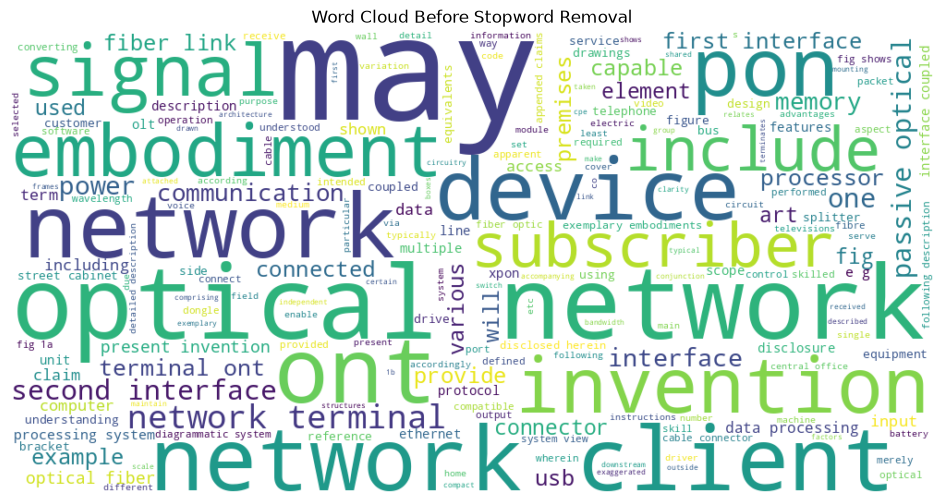

In [59]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud_before = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(tokens))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_before, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Before Stopword Removal")
plt.show()

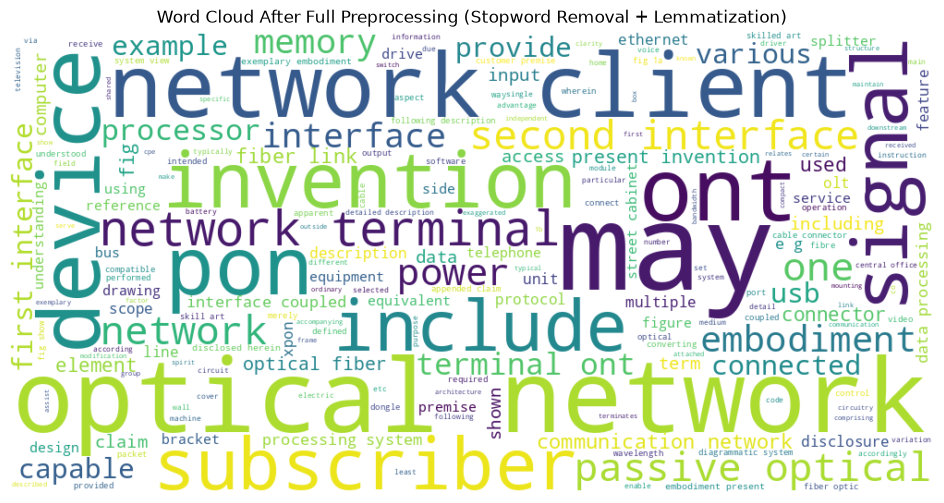

In [60]:
wordcloud_after = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(lemmatized_tokens))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_after, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud After Full Preprocessing (Stopword Removal + Lemmatization)")
plt.show()

### Observation

The word cloud before preprocessing is dominated by common English words because they occur frequently throughout the patent text. After the full preprocessing pipeline, technical and content-bearing terms become more prominent, making the main subject of the patent easier to identify visually.

The word cloud provides an intuitive illustration of the effect of preprocessing, although it does not replace quantitative evaluation.


## 22. Top Word Frequencies

A word-frequency plot is used to show which words occur most frequently in the fully processed patent text (after stopword removal and lemmatization). Unlike a word cloud, this visualization provides the actual frequency of each word.

The most frequent words can help identify the main technical concepts present in the patent and provide another way to inspect the effect of preprocessing.


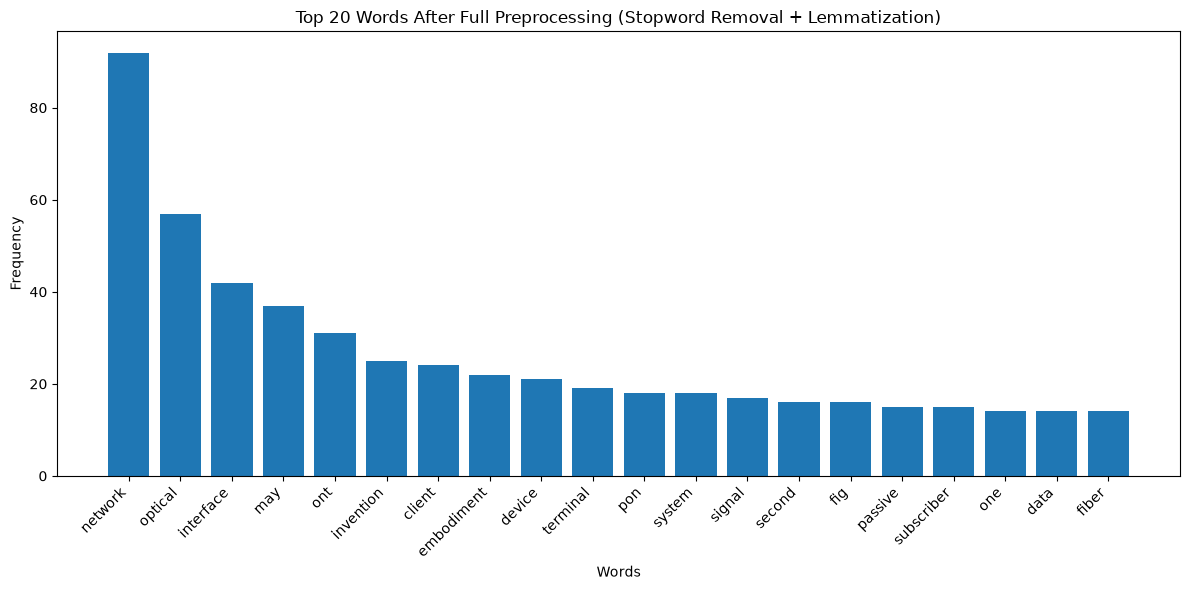

In [61]:
from collections import Counter
import matplotlib.pyplot as plt

# Count the most frequent words after the full preprocessing pipeline
word_counts = Counter(lemmatized_tokens)

top_words = word_counts.most_common(20)

words = [item[0] for item in top_words]
frequencies = [item[1] for item in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, frequencies)

plt.title("Top 20 Words After Full Preprocessing (Stopword Removal + Lemmatization)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

The frequency plot shows that the fully processed patent text is dominated by domain-relevant terms such as `network`, `optical`, `interface`, `ont`, `invention`, and `processor`. This suggests that after stopword removal and lemmatization, the representation places greater emphasis on words related to the technical content of the patent.

The frequency plot also provides exact counts for the most common words and therefore complements the word cloud visualization.


## 23. Assignment Requirements — Final Checklist

The preprocessing approach in this notebook was developed by examining the patent data first and then selecting preprocessing techniques based on the observed characteristics of the text.

| Assignment Requirement          | How It Is Addressed                                                                                                           |
| ------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| Explain what the technique is   | Each selected preprocessing technique is introduced and explained                                                             |
| Explain why it is required      | Each technique includes an observation and decision based on the patent text                                                  |
| Explain how it works internally | The overall preprocessing pipeline and individual operations are explained                                                    |
| Real-world applications         | Applications to patent search, classification, similarity analysis, and information extraction are discussed                  |
| Assumptions                     | The assumptions made about language, capitalization, numbers, and technical terminology are documented                        |
| Advantages                      | The benefits of normalization, vocabulary reduction, and information preservation are discussed                               |
| Limitations                     | Limitations such as tokenization of hyphenated terms and errors in general-purpose lemmatization are demonstrated             |
| Python implementation           | Preprocessing operations are implemented using Python                                                                         |
| Compare related techniques      | Stemming and lemmatization are compared using the same representative words                                                   |
| Evaluation                      | Token counts, vocabulary size, changed tokens, and technical-term retention are examined                                      |
| Raw-to-processed transformation | A representative patent passage is shown at different preprocessing stages                                                    |
| Justify selected steps          | A dedicated comparison table explains why each preprocessing step was selected or rejected                                    |
| Avoid unnecessary preprocessing | Techniques such as aggressive punctuation removal and stemming are rejected when they are not appropriate for the patent text |

### Final Principle

The main objective of the notebook is not to apply as many preprocessing techniques as possible. Instead, the preprocessing steps are selected according to the characteristics of the patent text and the intended downstream NLP task.

The final approach therefore follows the principle:

**Inspect the data → choose the appropriate preprocessing → evaluate the effect → preserve useful information.**


## 24. Conclusion

This notebook demonstrated the preprocessing of patent text through a sequence of data-driven steps. Rather than applying every available preprocessing technique, each step was examined and selected according to the characteristics of the patent data.

The experiments showed that patent text contains important technical terms, numbers, abbreviations, and specialized expressions that should not be removed blindly. Lowercasing, tokenization, stopword removal, and lemmatization were found to be useful, while aggressive stemming was rejected because it produced less interpretable word forms.

The final preprocessing strategy aims to produce a more consistent representation of the patent text while preserving domain-specific information. The effectiveness of this strategy should ultimately be judged by how well the processed text supports the intended downstream NLP task.
